In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
#生成数据集
n_train = 50
x_train,_ = torch.sort(torch.rand(n_train)*5) #0-1分布，扩展到0-5


In [3]:
x_train

tensor([0.0155, 0.2031, 0.2580, 0.3101, 0.3758, 0.3957, 0.5025, 0.7479, 0.7785,
        0.8046, 1.0052, 1.0336, 1.1133, 1.1986, 1.3455, 1.9770, 1.9837, 2.0355,
        2.1143, 2.1737, 2.3379, 2.4888, 2.7549, 2.7609, 2.8036, 2.8558, 2.8838,
        3.0550, 3.1019, 3.1420, 3.1451, 3.1597, 3.4512, 3.4636, 3.4871, 3.6106,
        3.6865, 3.8086, 3.8187, 3.9992, 4.0612, 4.2657, 4.2769, 4.5181, 4.6116,
        4.6341, 4.7366, 4.7457, 4.9145, 4.9740])

In [5]:
def f(x):
    return 2*torch.sin(x)+x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,)) # 训练样本的输出
x_test = torch.arange(0, 5, 0.1) # 测试样本
y_truth = f(x_test) # 测试样本的真实输出
n_test = len(x_test) # 测试样本数
n_test


50

In [9]:
"""绘制所有的训练样本（样本由圆圈表示），不带噪声项的真实数据生成函数f（标记为“Truth”），
以及学习得到的预测函数（标记为“Pred”）"""

'绘制所有的训练样本（样本由圆圈表示），不带噪声项的真实数据生成函数f（标记为“Truth”），\n以及学习得到的预测函数（标记为“Pred”）'

In [8]:
def plot_kernel_reg(y_hat):
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'],
            xlim=[0, 5], ylim=[-1, 5])
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);


In [10]:
# 基于平均汇聚来计算所有训练样本输出值的平均值

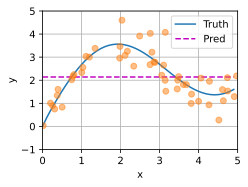

In [11]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)


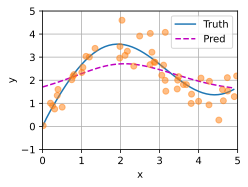

In [12]:
# X_repeat的形状:(n_test,n_train),
# 每一行都包含着相同的测试输入（例如：同样的查询）
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# x_train包含着键。attention_weights的形状：(n_test,n_train),
# 每一行都包含着要在给定的每个查询的值（y_train）之间分配的注意力权重
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
# y_hat的每个元素都是值的加权平均值，其中的权重是注意力权重
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)


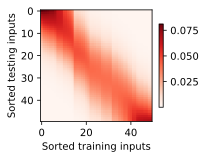

In [13]:
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
xlabel='Sorted training inputs',
ylabel='Sorted testing inputs')
# 观察注意力的权重。这里测试数据的输入相当于查询，而训练数据的输入相当于键。因为两个输入都是经过排序的，因此由观察可知“查询‐键”对越接近，注意力汇聚的注意力权重就越高

In [14]:
#批量矩阵乘法
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
torch.bmm(X, Y).shape


torch.Size([2, 1, 6])

In [15]:
#可以使用小批量矩阵乘法来计算小批量数据中的加权平均值
weights = torch.ones((2, 10)) * 0.1
values = torch.arange(20.0).reshape((2, 10))
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))


tensor([[[ 4.5000]],

        [[14.5000]]])

In [16]:
#注意力汇聚

In [18]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))
        
    def forward(self, queries, keys, values):
        # queries和attention_weights的形状为(查询个数，“键－值”对个数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w)**2 / 2, dim=1)
        # values的形状为(查询个数，“键－值”对个数)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                values.unsqueeze(-1)).reshape(-1)


In [19]:
# X_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((n_train, 1))
# Y_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((n_train, 1))
# keys的形状:('n_train'，'n_train'-1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# values的形状:('n_train'，'n_train'-1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))


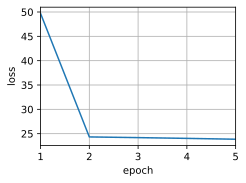

In [20]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    trainer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    animator.add(epoch + 1, float(l.sum()))
    

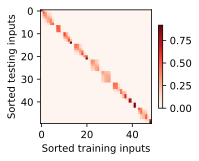

In [21]:
d2l.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
                    xlabel='Sorted training inputs',
                    ylabel='Sorted testing inputs')